# Genre, Budget & ROI Exploration

### Questions Explored:
* What films are the most expensive to make?
* Growth rate of different genres (popularity, number of movies produced, budget allocation)
* Which genres deliver the most consistent ROI year to year, and which ones are the most unpredictable?

In [38]:
import pandas as pd
df = pd.read_csv('movie_roi.csv')

df.head()


,movie,year,production_budget,domestic_gross,foreign_gross,worldwide_gross,month,profit,profit_margin,roi,...,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western,no_reported_box_office
0,Avatar,2009,425000000,760507625,2015837654,2776345279,12,2.351345e+09,0.846921,5.532577,...,0,0,0,0,1,0,0,0,0,False
1,Pirates of the Caribbean: On Stranger Tides,2011,410600000,241063875,804600000,1045663875,5,6.350639e+08,0.607331,1.546673,...,0,0,0,0,0,0,0,0,0,False
2,Avengers: Age of Ultron,2015,330600000,459005868,944008095,1403013963,5,1.072414e+09,0.764364,3.243841,...,0,0,0,0,1,0,0,0,0,False
3,Avengers: Infinity War,2018,300000000,678815482,1369318718,2048134200,4,1.748134e+09,0.853525,5.827114,...,0,0,0,0,0,0,0,0,0,False
4,Justice League,2017,300000000,229024295,426920914,655945209,11,3.559452e+08,0.542645,1.186484,...,0,0,0,0,1,0,0,0,0,False


#### Question 1: What films are the most expensive to make?

In [39]:
# Return the top 10 films by production budget
df.nlargest(10, 'production_budget')[['movie', 'year', 'production_budget']]

,movie,year,production_budget
0,Avatar,2009,425000000
1,Pirates of the Caribbean: On Stranger Tides,2011,410600000
2,Avengers: Age of Ultron,2015,330600000
3,Avengers: Infinity War,2018,300000000
4,Justice League,2017,300000000
5,Spectre,2015,300000000
6,The Dark Knight Rises,2012,275000000
7,Solo: A Star Wars Story,2018,275000000
8,The Lone Ranger,2013,275000000
9,John Carter,2012,275000000


##### Findings:
* The top 10 most expensive films are dominated by blockbuster franchise entries
  * Avatar, Pirates of the Caribbean, several Avengers films
  * All released between 2009–2018.

In [40]:
# List of one-hot encoded genre columns in the dataset (1 = film belongs to that genre, 0 = it doesn't).
# A film can belong to multiple genres at once.
genre_cols = ['Action','Adventure','Animation','Comedy','Crime','Documentary','Drama','Family',
              'Fantasy','History','Horror','Music','Mystery','Romance','Science Fiction',
              'TV Movie','Thriller','War','Western']


# For each genre, filter to films flagged with that genre (column == 1),
# then calculate the average production_budget for that subset.
# Result is a dictionary mapping genre name -> average budget.
avg_budget = {g: df[df[g]==1]['production_budget'].mean() for g in genre_cols}


# Convert the dictionary to a Series and sort descending,
# so the most expensive genres to produce appear first.
pd.Series(avg_budget).sort_values(ascending=False)

Adventure          1.102920e+08
Fantasy            1.025870e+08
Animation          9.269907e+07
Science Fiction    8.608775e+07
Family             8.239078e+07
Action             8.035261e+07
Western            5.546667e+07
War                4.231489e+07
Comedy             3.840737e+07
Crime              3.392873e+07
Thriller           3.362943e+07
History            3.053692e+07
Mystery            2.908926e+07
Music              2.707727e+07
Drama              2.700755e+07
Romance            2.654710e+07
Horror             1.862958e+07
Documentary        7.267000e+06
TV Movie           3.083333e+06
dtype: float64

In [41]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Shared style for all charts -- light grid, clean look, matching the team's charts
plt.rcParams.update({
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

def dollar_formatter(x, pos):
    """Format axis numbers as $XM or $XB instead of raw numbers."""
    if x >= 1e9:
        return f'${x/1e9:.0f}B'
    elif x >= 1e6:
        return f'${x/1e6:.0f}M'
    return f'${x:,.0f}'

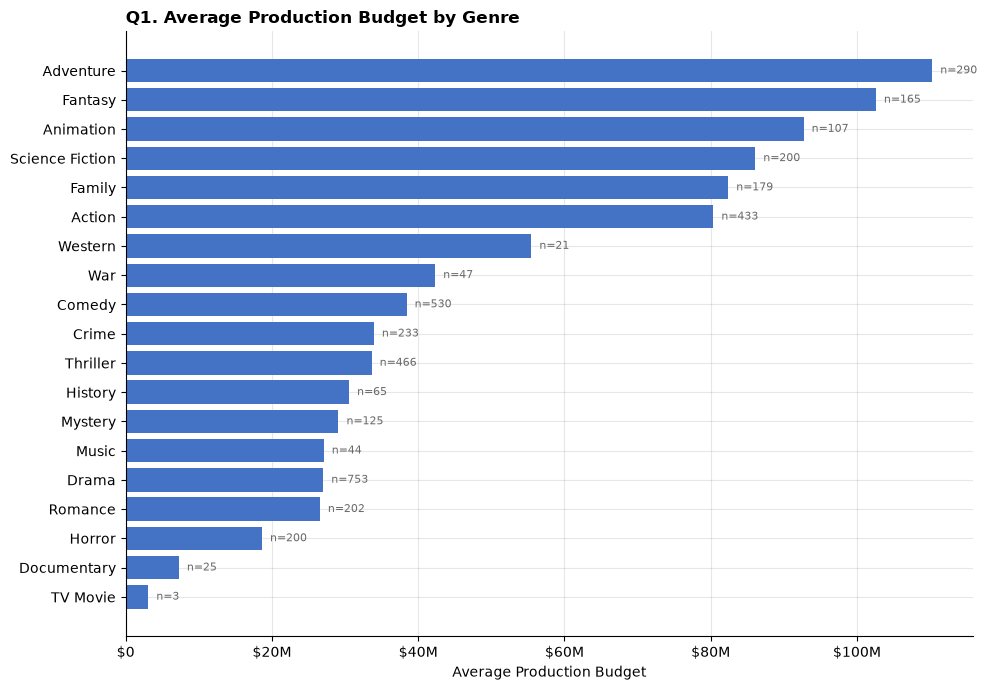

In [42]:
avg_budget_series = pd.Series(avg_budget).sort_values(ascending=False)
counts = {g: df[df[g]==1].shape[0] for g in genre_cols}
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(avg_budget_series.index, avg_budget_series.values, color='#4472C4')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(dollar_formatter))
ax.set_xlabel('Average Production Budget')
ax.set_title('Q1. Average Production Budget by Genre', fontweight='bold', loc='left')
for i, g in enumerate(avg_budget_series.index):
    ax.text(avg_budget_series[g] + avg_budget_series.max()*0.01, i,
            f'n={counts[g]}', va='center', fontsize=8, color='dimgray')
plt.tight_layout()
plt.savefig('q1_avg_budget_by_genre.png', dpi=150, facecolor='white')
plt.show()

##### Findings:
* Consistently the most expensive genres to produce:
  * Adventure: ~$110M avg
  * Fantasy: ~$103M avg
  * Animation: ~$93M avg 
* The cheapest genres to produce:
  * Documentary: ~$7.3M avg
  * TV Movie: ~$3.1M avg

#### Question 2: Growth Rate of Different Genres (Volume, Popularity, Budget Allocation)

In [43]:
# Count how many films exist for each release year, sorted chronologically.
# Used to check whether the dataset has enough films per year (or decade)
df['year'].value_counts().sort_index()

year
1946      1
1968      1
1976      1
1977      1
1979      1
1980      2
1982      3
1984      2
1985      1
1986      2
1988      2
1991      1
1992      1
1994      1
1995      5
1996      2
1997      3
1998      2
1999      2
2000      2
2001      1
2002      2
2004      5
2005      1
2006      2
2007      1
2008      2
2009      2
2010    188
2011    192
2012    171
2013    184
2014    184
2015    206
2016    167
2017    131
2018    124
2019      3
Name: count, dtype: int64

##### Findings:
* 96.8% of the dataset (1,550 of 1,602 films) falls between 2010–2019.
* Remaining 63 years (1946–2009) combined only have 52 films.
* Genre growth should be measured within 2010–2019.

In [44]:
# Filter the dataset down to films released between 2010 and 2019.
recent = df[(df['year'] >= 2010) & (df['year'] <= 2019)]

In [45]:
# For each genre, filter to films flagged with that genre, then count
# how many were released per year.
genre_by_year = {}
for g in genre_cols:
    genre_by_year[g] = recent[recent[g]==1].groupby('year').size()

pd.DataFrame(genre_by_year).fillna(0)

,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
year,,,,,,,,,,,,,,,,,,,
2010,45,29.0,10.0,75,28,7.0,96,31.0,21.0,2.0,20,4.0,19.0,36.0,13.0,1.0,49,3.0,3.0
2011,50,29.0,14.0,72,24,2.0,94,23.0,17.0,6.0,20,4.0,16.0,30.0,22.0,1.0,59,6.0,2.0
2012,45,24.0,9.0,65,26,5.0,70,13.0,17.0,4.0,22,7.0,10.0,32.0,20.0,1.0,54,3.0,1.0
2013,49,28.0,12.0,53,35,6.0,81,17.0,19.0,7.0,25,3.0,9.0,19.0,26.0,0.0,54,1.0,2.0
2014,50,31.0,11.0,51,27,1.0,95,19.0,14.0,6.0,18,5.0,7.0,19.0,24.0,0.0,50,8.0,3.0
2015,45,33.0,10.0,64,27,2.0,98,17.0,14.0,7.0,31,8.0,19.0,23.0,24.0,0.0,66,7.0,4.0
2016,43,41.0,14.0,56,18,0.0,82,21.0,16.0,13.0,22,2.0,17.0,16.0,20.0,0.0,46,6.0,4.0
2017,45,28.0,15.0,44,13,1.0,63,19.0,21.0,7.0,17,3.0,10.0,12.0,21.0,0.0,27,7.0,1.0
2018,39,32.0,8.0,34,22,1.0,49,13.0,20.0,10.0,18,5.0,12.0,10.0,22.0,0.0,40,4.0,1.0


In [46]:
# Compare genre film counts at the start (2010) vs. end (2018) of the decade.
# 2019 excluded (only 3 films total, incomplete data collection year).
genre_by_year_df = pd.DataFrame(genre_by_year).fillna(0)

genre_growth = pd.DataFrame({
    '2010_count': genre_by_year_df.loc[2010],
    '2018_count': genre_by_year_df.loc[2018],
})

genre_growth['pct_change'] = (
    (genre_growth['2018_count'] - genre_growth['2010_count'])
    / genre_growth['2010_count'].replace(0, pd.NA)
) * 100

genre_growth.sort_values('pct_change', ascending=False)

,2010_count,2018_count,pct_change
History,2.0,10.0,400.000000
Science Fiction,13.0,22.0,69.230769
War,3.0,4.0,33.333333
Music,4.0,5.0,25.000000
Adventure,29.0,32.0,10.344828
Fantasy,21.0,20.0,-4.761905
Horror,20.0,18.0,-10.000000
Action,45.0,39.0,-13.333333
Thriller,49.0,40.0,-18.367347
Animation,10.0,8.0,-20.000000


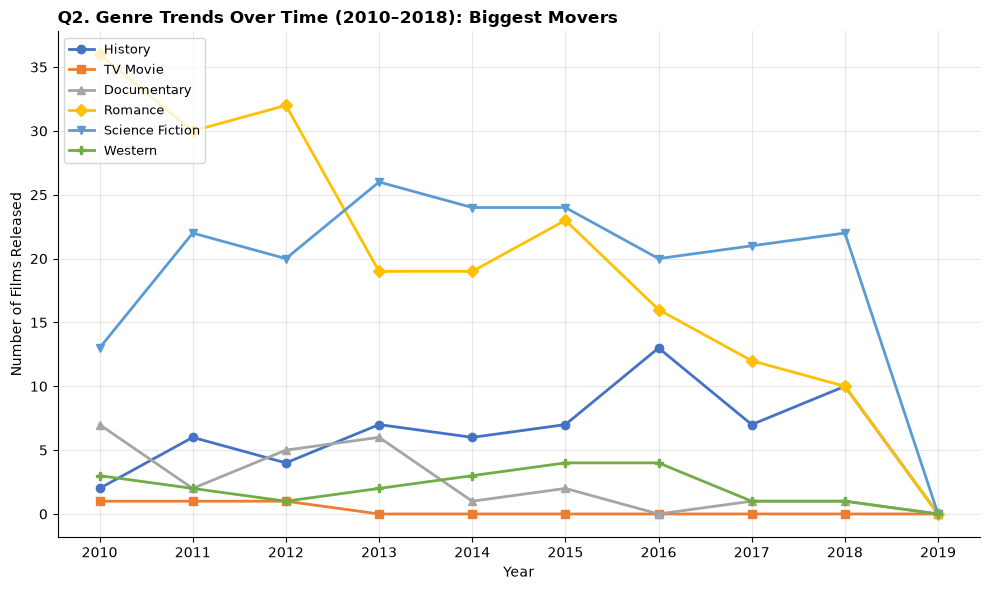

In [47]:
genre_by_year_df = pd.DataFrame(genre_by_year).fillna(0)
# Find the 6 genres with the biggest % change from 2010 to 2018
growth = pd.DataFrame({
    '2010': genre_by_year_df.loc[2010],
    '2018': genre_by_year_df.loc[2018],
})
growth['pct_change'] = (growth['2018'] - growth['2010']) / growth['2010'].replace(0, pd.NA) * 100
biggest_movers = growth.reindex(growth['pct_change'].abs().sort_values(ascending=False).index).head(6)
fig, ax = plt.subplots(figsize=(10, 6))
markers = ['o', 's', '^', 'D', 'v', 'P']
colors = ['#4472C4', '#ED7D31', '#A5A5A5', '#FFC000', '#5B9BD5', '#70AD47']
for i, g in enumerate(biggest_movers.index):
    ax.plot(genre_by_year_df.index, genre_by_year_df[g], marker=markers[i],
            label=g, color=colors[i], linewidth=2, markersize=6)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Films Released')
ax.set_title('Q2. Genre Trends Over Time (2010–2018): Biggest Movers', fontweight='bold', loc='left')
ax.set_xticks(genre_by_year_df.index)
ax.legend(loc='upper left', frameon=True, fontsize=9)
plt.tight_layout()
plt.savefig('q2_genre_trend_lines.png', dpi=150, facecolor='white')
plt.show()

##### Finding:
* Saw the sharpest growth:
  * History: +400%
  * Science Fiction: +69%
* Saw the most decline:
  * Documentary: -86%
  * Romance: -72%
  * Western: -67%

#### Question 3: Which genres deliver the most consistent ROI, and which are the most unpredictable?

In [48]:
MIN_FILMS = 10
roi_volatility_rows = []
for g in genre_cols:
    subset = df[df[g] == 1]['roi'].dropna()
    if len(subset) >= MIN_FILMS:
        mean_roi = subset.mean()
        std_roi = subset.std()
        cv = std_roi / mean_roi if mean_roi != 0 else float('nan')
        roi_volatility_rows.append({
            'genre': g, 'count': len(subset),
            'mean_roi': mean_roi, 'std_roi': std_roi,
            'coefficient_of_variation': cv
        })

roi_volatility = pd.DataFrame(roi_volatility_rows).set_index('genre')
roi_volatility.sort_values('coefficient_of_variation')

,count,mean_roi,std_roi,coefficient_of_variation
genre,,,,
Animation,103,2.886306,3.056665,1.059023
Family,172,2.509999,2.922001,1.164144
Action,409,1.844554,2.535717,1.374704
Fantasy,162,2.248047,3.136819,1.395353
Adventure,285,2.256334,3.200541,1.418469
Science Fiction,192,2.607354,3.847995,1.475824
Comedy,505,2.512965,3.910538,1.556145
Romance,196,2.888372,4.563022,1.579790
Music,43,2.233154,3.812172,1.707080


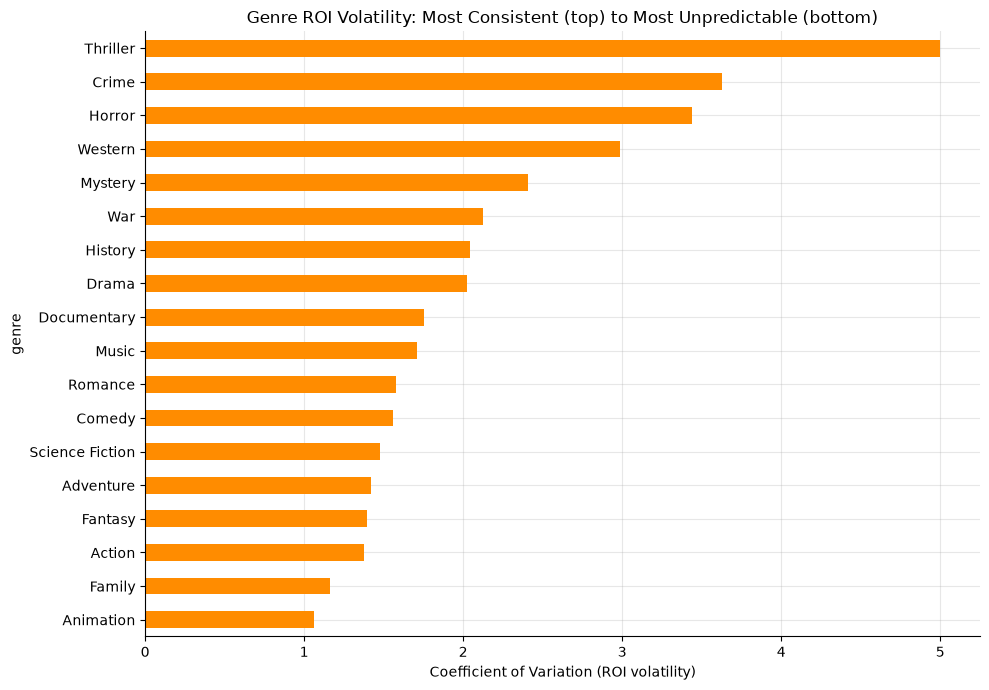

In [49]:
fig, ax = plt.subplots(figsize=(10, 7))
roi_volatility['coefficient_of_variation'].sort_values().plot(kind='barh', ax=ax, color='darkorange')
ax.set_xlabel('Coefficient of Variation (ROI volatility)')
ax.set_title('Genre ROI Volatility: Most Consistent (top) to Most Unpredictable (bottom)')
plt.tight_layout()
plt.savefig('q3_genre_roi_volatility.png', dpi=150)
plt.show()

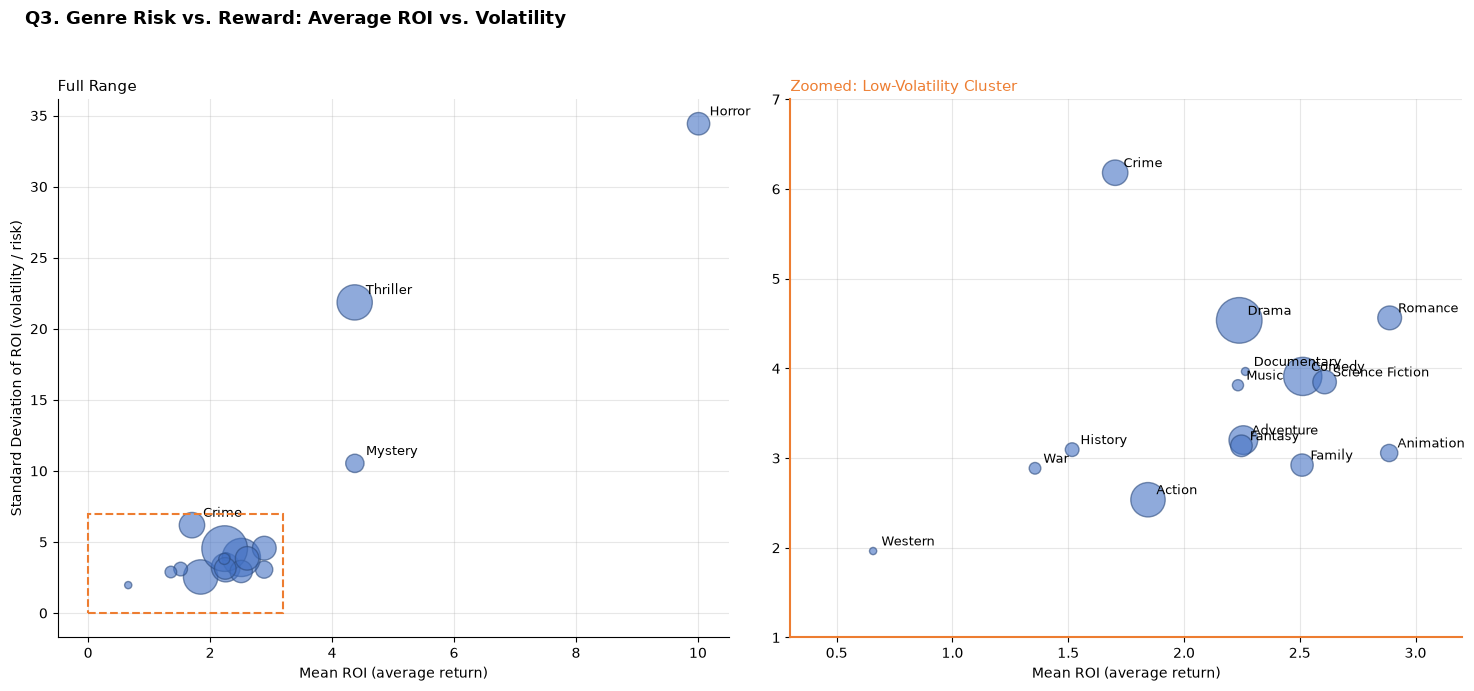

In [50]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
for ax in (ax1, ax2):
    ax.scatter(roi_volatility['mean_roi'], roi_volatility['std_roi'],
               s=roi_volatility['count']*1.5, alpha=0.6, color='#4472C4',
               edgecolor='#2c4a7c', zorder=3)
# Left panel: full range, label only the clear outliers
outliers = ['Horror', 'Thriller', 'Mystery', 'Crime']
for genre in outliers:
    x, y = roi_volatility.loc[genre, 'mean_roi'], roi_volatility.loc[genre, 'std_roi']
    ax1.annotate(genre, (x, y), fontsize=9, xytext=(8, 6), textcoords='offset points')
ax1.set_xlabel('Mean ROI (average return)')
ax1.set_ylabel('Standard Deviation of ROI (volatility / risk)')
ax1.set_title('Full Range', fontsize=11, loc='left')
ax1.add_patch(plt.Rectangle((0, 0), 3.2, 7, fill=False, edgecolor='#ED7D31',
                             linewidth=1.5, linestyle='--', zorder=4))
# Right panel: zoomed into the dense cluster, everything labeled
cluster = roi_volatility[(roi_volatility['mean_roi'] <= 3.2) & (roi_volatility['std_roi'] <= 7)]
for genre in cluster.index:
    x, y = cluster.loc[genre, 'mean_roi'], cluster.loc[genre, 'std_roi']
    ax2.annotate(genre, (x, y), fontsize=9, xytext=(6, 4), textcoords='offset points')
ax2.set_xlim(0.3, 3.2)
ax2.set_ylim(1, 7)
ax2.set_xlabel('Mean ROI (average return)')
ax2.set_title('Zoomed: Low-Volatility Cluster', fontsize=11, loc='left', color='#ED7D31')
for spine in ax2.spines.values():
    spine.set_edgecolor('#ED7D31')
    spine.set_linewidth(1.5)
fig.suptitle('Q3. Genre Risk vs. Reward: Average ROI vs. Volatility',
             fontweight='bold', x=0.02, ha='left', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('q3_roi_risk_reward_scatter.png', dpi=150, facecolor='white')
plt.show()

##### Finding:
* Most consistent ROI:
  * Animation
  * Family
* Most unpredictable:
  * Thriller
  * Crime
  * Horror
    * Huge average ROI (~10x) but massive variance.
      * Some films are huge hits while others likely lose money.

#### Summary: 
* 96.8% of data is 2010–2019
* Adventure/Fantasy/Animation are priciest genres
* Documentary/TV Movie cheapest
* History/Sci-Fi grew most
* Documentary/Romance declined most
* Animation/Family/Action most ROI-consistent
* Horror/Thriller most inconsistent